# 6. Squat Rep Counting (Google Colab)

This notebook starts after step 5 has produced processed squat feature files.

Input:
- `squat_feature_index.csv`
- `squat_features/*.npy`

Output:
- predicted rep counts per video
- a prototype FSM-based squat counter
- basic evaluation against labeled squat counts

## Reason, Approach, Idea, Result Interpretation

**Reason for this section**
- This stage turns processed squat features into rep-count predictions.
- It is the first end-to-end counting baseline after pose and feature extraction are complete.

**Approach**
- Load the engineered squat feature files.
- Use an FSM-based counter driven by signals such as `knee_flex`.
- Compare predicted counts with labeled counts and export evaluation results.

**Core idea**
- Counting should be based on movement phases like `UP`, `DESCENDING`, `BOTTOM`, and `ASCENDING`.
- A simple FSM gives a strong baseline before moving to more complex temporal models.

**How to interpret results**
- `MAE` is the average rep-count error per video. Lower is better.
- `RMSE` highlights large-count failures more strongly than MAE.
- `Within-1 accuracy` shows how often the prediction is within one rep of the label.
- Train and valid should be interpreted separately when tuning thresholds and judging generalization.


## 0. Connect Google Drive

**Why this section exists**
This notebook reads the squat feature outputs from Drive and writes tuned counting results back to Drive, so the mount must exist before any path variables are defined.

**Approach / idea**
Mount Google Drive first, then define the Drive-based project root and downstream file paths used by the rep-counting pipeline.

**Result interpretation**
If the mount works here, the `1. Paths` section should point to accessible files under `/content/drive` rather than failing on missing paths.


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 1. Paths

**Why this section exists**
Rep counting depends on the feature outputs from step 5, so the notebook needs explicit locations for the feature index, summaries, and result files.

**Approach / idea**
Set the Drive-based paths once at the top and use them consistently throughout the notebook.

**Result interpretation**
If these paths are wrong, the rest of the notebook will fail for file reasons rather than modeling reasons.


In [2]:
from pathlib import Path

DRIVE_PROJECT_ROOT = Path('/content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection')
ANNOTATION_DIR = DRIVE_PROJECT_ROOT / 'Data' / 'LLSP' / 'annotation_cleaned'

SQUAT_FEATURE_INDEX_CSV = ANNOTATION_DIR / 'squat_feature_index.csv'
RUN_SUMMARY_CSV = ANNOTATION_DIR / 'squat_feature_summary.csv'
REP_COUNT_RESULTS_CSV = ANNOTATION_DIR / 'squat_rep_count_results.csv'

print('ANNOTATION_DIR =', ANNOTATION_DIR)
print('SQUAT_FEATURE_INDEX_CSV =', SQUAT_FEATURE_INDEX_CSV)
print('RUN_SUMMARY_CSV =', RUN_SUMMARY_CSV)
print('REP_COUNT_RESULTS_CSV =', REP_COUNT_RESULTS_CSV)

ANNOTATION_DIR = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned
SQUAT_FEATURE_INDEX_CSV = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_feature_index.csv
RUN_SUMMARY_CSV = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_feature_summary.csv
REP_COUNT_RESULTS_CSV = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_rep_count_results.csv


## 2. Imports

**Why this section exists**
This notebook relies on numerical operations, result aggregation, and visualization for debugging the counter behavior.

**Approach / idea**
Load the required Python modules early so the later sections focus on counting logic and evaluation.

**Result interpretation**
If imports fail here, stop and fix the environment before interpreting any counting results.


In [3]:
from dataclasses import dataclass
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Load Feature Index

**Why this section exists**
The feature index is the list of squat examples that will be counted and evaluated in this stage.

**Approach / idea**
Load the index, confirm the files exist, and establish the working set before applying any FSM logic.

**Result interpretation**
A clean load here means the rep-counting results will reflect the model logic rather than missing feature artifacts.


In [4]:
feature_index = pd.read_csv(SQUAT_FEATURE_INDEX_CSV)
feature_index.head()

,name,pose_path,feature_path,type,split,count
0,test2340.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,4.0
1,stu4_66.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,27.0
2,stu9_63.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,20.0
3,stu1_68.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,20.0
4,stu6_62.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,20.0


In [5]:
print('rows =', len(feature_index))
print('missing feature files =', int((~feature_index['feature_path'].map(lambda p: Path(p).exists())).sum()))

rows = 118
missing feature files = 0


## 3b. Verify Input Artifacts

**Why this section exists**
If steps 5 and 6 point to different files, the rep metrics can stay unchanged even after upstream improvements.

**Approach / idea**
Inspect the exact Drive files that this notebook is reading, print modification times, and compare the loaded summary means with the expected step-5 outputs.

**Result interpretation**
If the printed means or paths do not match the latest step-5 run, stop here and fix the artifact paths before interpreting any rep-count metrics.


In [6]:
run_summary = pd.read_csv(RUN_SUMMARY_CSV)
sample_feature_path = Path(feature_index.iloc[0]['feature_path'])
sample_arr = np.load(sample_feature_path)

print('SQUAT_FEATURE_INDEX_CSV =', SQUAT_FEATURE_INDEX_CSV)
print('RUN_SUMMARY_CSV =', RUN_SUMMARY_CSV)
print('sample_feature_path =', sample_feature_path)
print('sample_feature_exists =', sample_feature_path.exists())
print('sample_feature_shape =', sample_arr.shape)
print('index_mtime =', SQUAT_FEATURE_INDEX_CSV.stat().st_mtime)
print('summary_mtime =', RUN_SUMMARY_CSV.stat().st_mtime)
print('sample_feature_mtime =', sample_feature_path.stat().st_mtime)
print('\nsummary means from RUN_SUMMARY_CSV')
print(run_summary[['frames_valid', 'mean_conf']].mean(numeric_only=True))
print('\nfirst feature paths from loaded index')
print(feature_index['feature_path'].head().to_string(index=False))


SQUAT_FEATURE_INDEX_CSV = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_feature_index.csv
RUN_SUMMARY_CSV = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_feature_summary.csv
sample_feature_path = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_features/test2340_squat_features.npy
sample_feature_exists = True
sample_feature_shape = (300, 16)
index_mtime = 1773350139.0
summary_mtime = 1773350138.0
sample_feature_mtime = 1773350074.0

summary means from RUN_SUMMARY_CSV
frames_valid    872.042373
mean_conf         0.940858
dtype: float64

first feature paths from loaded index
/content/drive/MyDrive/FinalProjectCV/CV_Image_...
/content/drive/MyDrive/FinalProjectCV/CV_Image_...
/content/drive/MyDrive/FinalProjectCV/CV_Image_...
/content/drive/MyDrive/FinalProjectCV/CV_Image_...
/content/drive/MyDrive/FinalProjectCV/CV_Image_...


## 4. Feature Schema

These columns match the output order from step 5.

**Why this section exists**
The counter assumes certain feature columns such as `knee_flex`, `hip_drop`, and `frame_valid` are present and correctly named.

**Approach / idea**
Declare the expected schema explicitly so feature loading and counter logic stay aligned.

**Result interpretation**
If the schema changes upstream, this section is where incompatibilities should surface clearly.


In [7]:
FEATURE_COLUMNS = [
    'frame_idx',
    'left_knee_angle',
    'right_knee_angle',
    'avg_knee_angle',
    'knee_flex',
    'left_hip_angle',
    'right_hip_angle',
    'avg_hip_angle',
    'hip_center_y',
    'knee_center_y',
    'ankle_center_y',
    'hip_drop',
    'leg_extension',
    'hip_velocity',
    'frame_valid',
    'mean_conf',
]

len(FEATURE_COLUMNS)

16

## 5. Load One Feature File

**Why this section exists**
Before counting everything, verify that one processed feature file loads correctly and looks structurally sound.

**Approach / idea**
Open one sample file and inspect its shape and columns before running the FSM.

**Result interpretation**
If a single sample already looks malformed, full-batch evaluation would be misleading.


In [8]:
def load_feature_frame(path: Path) -> pd.DataFrame:
    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] != len(FEATURE_COLUMNS):
        raise ValueError(f'Expected [T, {len(FEATURE_COLUMNS)}], got {arr.shape} for {path}')
    return pd.DataFrame(arr, columns=FEATURE_COLUMNS)


sample_row = feature_index.iloc[0]
sample_df = load_feature_frame(Path(sample_row['feature_path']))
print('video =', sample_row['name'])
print('shape =', sample_df.shape)
sample_df.head()

video = test2340.mp4
shape = (300, 16)


,frame_idx,left_knee_angle,right_knee_angle,avg_knee_angle,knee_flex,left_hip_angle,right_hip_angle,avg_hip_angle,hip_center_y,knee_center_y,ankle_center_y,hip_drop,leg_extension,hip_velocity,frame_valid,mean_conf
0,0.0,86.352844,90.348091,88.350464,91.649536,70.691925,84.789009,77.740463,0.000000e+00,0.755505,2.076810,0.755505,2.076810,4.377216e-08,1.0,0.968391
1,1.0,87.833275,90.829323,89.331299,90.668701,69.988403,84.587166,77.287781,4.377216e-08,0.750300,2.077808,0.750300,2.077808,0.000000e+00,1.0,0.990984
2,2.0,88.312500,90.441620,89.377060,90.622940,67.750572,82.363701,75.057137,0.000000e+00,0.716673,2.003230,0.716673,2.003230,-4.214235e-08,1.0,0.990503
3,3.0,88.429710,89.347824,88.888763,91.111237,65.941605,79.731735,72.836670,-4.051253e-08,0.668541,1.890939,0.668541,1.890939,0.000000e+00,1.0,0.991104
4,4.0,87.974617,87.171066,87.572845,92.427155,63.374439,76.536415,69.955429,0.000000e+00,0.619662,1.790800,0.619662,1.790800,2.025627e-08,1.0,0.987003


## 6. Counter Parameters

**Why this section exists**
The FSM behavior is governed by threshold values, so the initial configuration needs to be explicit and easy to inspect.

**Approach / idea**
Define a baseline threshold dictionary that the notebook can use for inspection, batch counting, and later tuning.

**Result interpretation**
These values are a starting point, not the final answer; weak metrics later usually mean this section needs tuning.


In [9]:
FSM_CFG = {
    'min_conf': 0.8,
    'min_valid_ratio': 0.5,
    'enter_down': 20.0,
    'enter_bottom': 55.0,
    'exit_bottom': 40.0,
    'back_to_up': 15.0,
    'min_bottom_frames': 2,
}

FSM_CFG

{'min_conf': 0.8,
 'min_valid_ratio': 0.5,
 'enter_down': 20.0,
 'enter_bottom': 55.0,
 'exit_bottom': 40.0,
 'back_to_up': 15.0,
 'min_bottom_frames': 2}

## 7. Squat FSM

**Why this section exists**
Rep counting here is implemented as a finite-state machine, so this section defines the actual counting logic.

**Approach / idea**
Use threshold-driven state transitions over the squat features to move through `UP`, `DESCENDING`, `BOTTOM`, and `ASCENDING`.

**Result interpretation**
If the predicted counts are wrong, this state logic and its thresholds are the primary mechanisms to inspect.


In [10]:
@dataclass
class CountResult:
    pred_count: int
    state_trace: list[str]
    event_frames: list[int]


def count_squat_reps(features: pd.DataFrame, cfg: dict) -> CountResult:
    count = 0
    state = 'UP'
    state_trace = []
    event_frames = []
    bottom_frames = 0

    for i, row in features.iterrows():
        valid_frame = (row['frame_valid'] >= cfg['min_valid_ratio']) and (row['mean_conf'] >= cfg['min_conf'])
        knee_flex = float(row['knee_flex'])

        if not valid_frame:
            state_trace.append(state)
            continue

        if state == 'UP':
            bottom_frames = 0
            if knee_flex > cfg['enter_down']:
                state = 'DESCENDING'

        elif state == 'DESCENDING':
            if knee_flex > cfg['enter_bottom']:
                state = 'BOTTOM'
                bottom_frames = 1
            elif knee_flex < cfg['back_to_up']:
                state = 'UP'

        elif state == 'BOTTOM':
            if knee_flex > cfg['exit_bottom']:
                bottom_frames += 1
            else:
                if bottom_frames >= cfg['min_bottom_frames']:
                    state = 'ASCENDING'
                else:
                    state = 'DESCENDING'

        elif state == 'ASCENDING':
            if knee_flex < cfg['back_to_up']:
                count += 1
                event_frames.append(int(row['frame_idx']))
                state = 'UP'
                bottom_frames = 0
            elif knee_flex > cfg['enter_bottom']:
                state = 'BOTTOM'
                bottom_frames = 1

        state_trace.append(state)

    return CountResult(pred_count=count, state_trace=state_trace, event_frames=event_frames)

## 8. Inspect One Count Trace

**Why this section exists**
Single-example inspection helps you see exactly how the FSM behaves on real squat signals before trusting aggregate metrics.

**Approach / idea**
Run the counter on one sample, then plot the key signals, thresholds, and state transitions over time.

**Result interpretation**
Use this view to diagnose under-counting, over-counting, jitter sensitivity, or poor threshold placement.


In [11]:
sample_result = count_squat_reps(sample_df, FSM_CFG)
true_count = float(sample_row['count'])

print('video =', sample_row['name'])
print('true_count =', true_count)
print('pred_count =', sample_result.pred_count)
print('event_frames =', sample_result.event_frames[:20])

video = test2340.mp4
true_count = 4.0
pred_count = 2
event_frames = [182, 239]


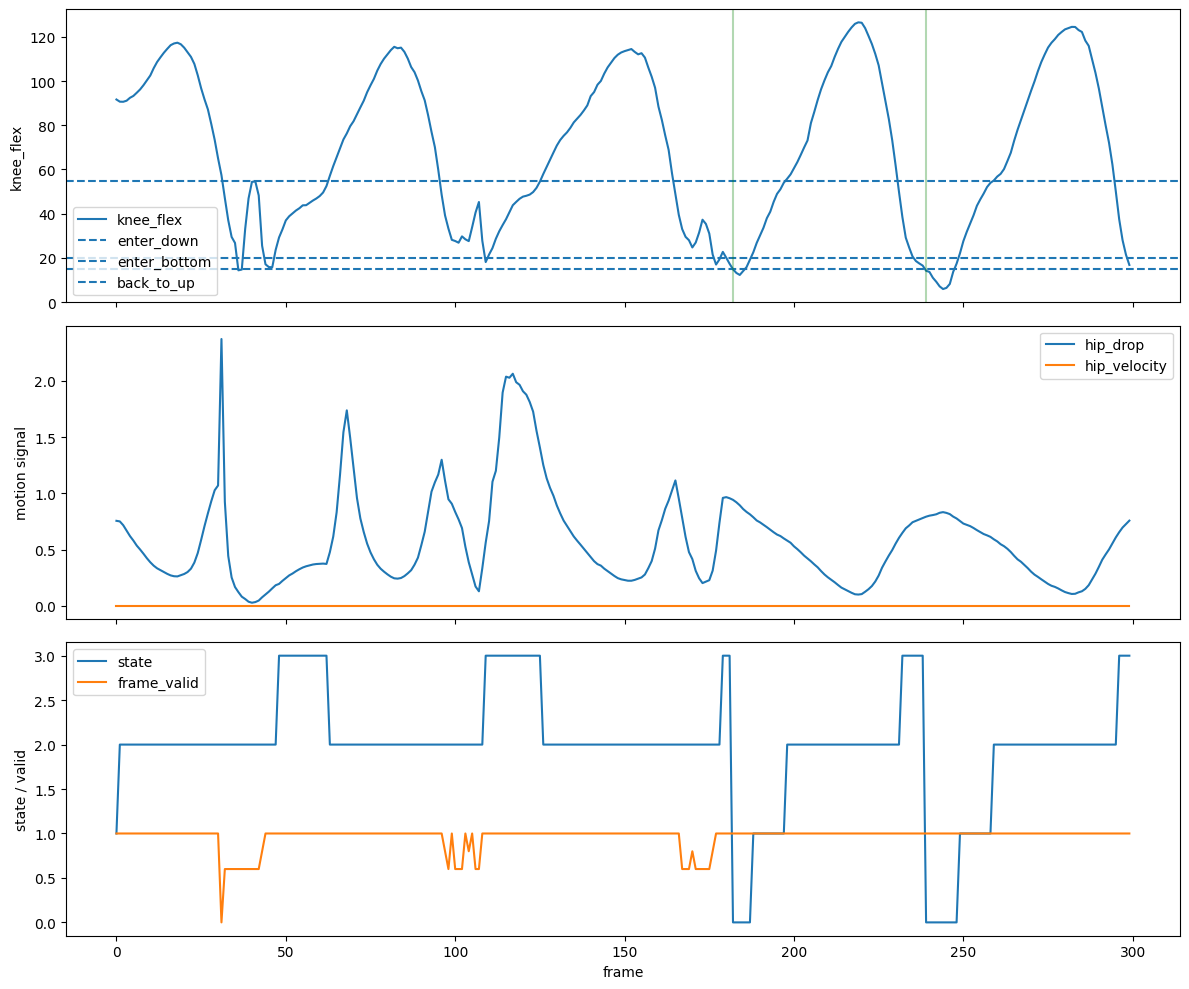

In [12]:
plot_df = sample_df.copy()
plot_df['state'] = sample_result.state_trace

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(plot_df['knee_flex'], label='knee_flex')
axes[0].axhline(FSM_CFG['enter_down'], linestyle='--', label='enter_down')
axes[0].axhline(FSM_CFG['enter_bottom'], linestyle='--', label='enter_bottom')
axes[0].axhline(FSM_CFG['back_to_up'], linestyle='--', label='back_to_up')
for frame in sample_result.event_frames:
    axes[0].axvline(frame, color='green', alpha=0.3)
axes[0].legend()
axes[0].set_ylabel('knee_flex')

axes[1].plot(plot_df['hip_drop'], label='hip_drop')
axes[1].plot(plot_df['hip_velocity'], label='hip_velocity')
axes[1].legend()
axes[1].set_ylabel('motion signal')

state_to_num = {'UP': 0, 'DESCENDING': 1, 'BOTTOM': 2, 'ASCENDING': 3}
axes[2].plot(plot_df['state'].map(state_to_num), label='state')
axes[2].plot(plot_df['frame_valid'], label='frame_valid')
axes[2].legend()
axes[2].set_ylabel('state / valid')
axes[2].set_xlabel('frame')

plt.tight_layout()
plt.show()

## 9. Batch Counting

**Why this section exists**
This section applies the current counter to the full squat subset and creates the result table used for evaluation.

**Approach / idea**
Loop over the feature index, run the FSM per video, and save per-video predictions and metadata.

**Result interpretation**
The batch output is the raw evidence for whether the current counter is usable or still needs tuning.


In [13]:
results = []

for i, row in feature_index.iterrows():
    features = load_feature_frame(Path(row['feature_path']))
    count_result = count_squat_reps(features, FSM_CFG)
    true_count = float(row['count']) if pd.notna(row['count']) else np.nan
    pred_count = float(count_result.pred_count)
    abs_error = abs(pred_count - true_count) if pd.notna(true_count) else np.nan

    results.append({
        'name': row['name'],
        'split': row.get('split', ''),
        'feature_path': row['feature_path'],
        'true_count': true_count,
        'pred_count': pred_count,
        'abs_error': abs_error,
        'events_found': len(count_result.event_frames),
        'frames_total': len(features),
        'frames_valid': int(features['frame_valid'].sum()),
        'mean_conf': float(features['mean_conf'].mean()),
    })

    if (i + 1) % 25 == 0 or (i + 1) == len(feature_index):
        print(f'[{i + 1}/{len(feature_index)}] counted')

results_df = pd.DataFrame(results)
results_df.to_csv(REP_COUNT_RESULTS_CSV, index=False)
print('saved =', REP_COUNT_RESULTS_CSV)

[25/118] counted
[50/118] counted
[75/118] counted
[100/118] counted
[118/118] counted
saved = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_rep_count_results.csv


## 10. Evaluation

**Why this section exists**
A rep counter is only useful if its errors are measured, so this section turns raw predictions into interpretable metrics.

**Approach / idea**
Compute aggregate error metrics and inspect worst examples to understand both average performance and failure modes.

**Result interpretation**
Treat these numbers as baseline quality indicators; they show whether the current FSM is good enough or still exploratory.


In [14]:
results_df.head()

,name,split,feature_path,true_count,pred_count,abs_error,events_found,frames_total,frames_valid,mean_conf
0,test2340.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,4.0,2.0,2.0,2,300,288,0.906618
1,stu4_66.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,27.0,7.0,20.0,7,1125,1021,0.858571
2,stu9_63.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,20.0,20.0,0.0,20,1350,1331,0.975102
3,stu1_68.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,20.0,1.0,19.0,1,936,936,0.994568
4,stu6_62.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,20.0,1.0,19.0,1,749,748,0.986690


In [15]:
print('MAE overall =', results_df['abs_error'].mean())
print('RMSE overall =', np.sqrt(np.mean((results_df['pred_count'] - results_df['true_count']) ** 2)))
print('Within-1 accuracy =', np.mean(results_df['abs_error'] <= 1.0))

MAE overall = 4.101694915254237
RMSE overall = 7.179301698727804
Within-1 accuracy = 0.5508474576271186


In [16]:
results_df.groupby('split')[['abs_error']].mean()

,abs_error
split,
train,4.088235
valid,4.187500


In [17]:
worst = results_df.sort_values('abs_error', ascending=False).head(15)
worst[['name', 'split', 'true_count', 'pred_count', 'abs_error', 'mean_conf', 'frames_valid']]

,name,split,true_count,pred_count,abs_error,mean_conf,frames_valid
53,stu2_68.mp4,train,25.0,3.0,22.0,0.671306,1222
94,stu9_65.mp4,train,24.0,2.0,22.0,0.993573,1648
1,stu4_66.mp4,train,27.0,7.0,20.0,0.858571,1021
4,stu6_62.mp4,train,20.0,1.0,19.0,0.986690,748
74,stu1_67.mp4,train,20.0,1.0,19.0,0.996337,1079
3,stu1_68.mp4,train,20.0,1.0,19.0,0.994568,936
6,stu7_67.mp4,train,29.0,11.0,18.0,0.993814,1601
107,stu8_62.mp4,valid,22.0,4.0,18.0,0.995858,1799
64,stu6_60.mp4,train,35.0,18.0,17.0,0.994441,1740
70,stu6_11.mp4,train,22.0,5.0,17.0,0.660836,904


## 11. Tune FSM on Train Split

This section tunes a small grid of FSM thresholds on the `train` split only. That keeps threshold selection separate from the `valid` split, which is used as the first real generalization check.

**Why this section exists**
Threshold tuning should happen on `train` so `valid` can remain the first honest check of generalization.

**Approach / idea**
Search a small grid of candidate threshold combinations, rank them by train performance, and keep the best configuration.

**Result interpretation**
Improvement here means the FSM can be calibrated; overfitting will show up if valid does not improve afterward.


In [18]:
TUNING_RESULTS_CSV = ANNOTATION_DIR / 'squat_rep_tuning_results.csv'
TUNED_REP_COUNT_RESULTS_CSV = ANNOTATION_DIR / 'squat_rep_count_results_tuned.csv'

def summarize_results(df: pd.DataFrame) -> dict:
    return {
        'rows': int(len(df)),
        'mae': float(df['abs_error'].mean()),
        'rmse': float(np.sqrt(np.mean((df['pred_count'] - df['true_count']) ** 2))),
        'within_1': float(np.mean(df['abs_error'] <= 1.0)),
    }


def evaluate_counter(index_df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    rows = []

    for _, row in index_df.iterrows():
        features = load_feature_frame(Path(row['feature_path']))
        count_result = count_squat_reps(features, cfg)
        true_count = float(row['count']) if pd.notna(row['count']) else np.nan
        pred_count = float(count_result.pred_count)
        rows.append({
            'name': row['name'],
            'split': row.get('split', ''),
            'feature_path': row['feature_path'],
            'true_count': true_count,
            'pred_count': pred_count,
            'abs_error': abs(pred_count - true_count) if pd.notna(true_count) else np.nan,
            'events_found': len(count_result.event_frames),
            'frames_total': len(features),
            'frames_valid': int(features['frame_valid'].sum()),
            'mean_conf': float(features['mean_conf'].mean()),
        })

    return pd.DataFrame(rows)


train_index = feature_index[feature_index['split'] == 'train'].reset_index(drop=True)
valid_index = feature_index[feature_index['split'] == 'valid'].reset_index(drop=True)

param_grid = {
    'min_conf': [0.7, 0.8, 0.9],
    'min_valid_ratio': [0.35, 0.5, 0.65],
    'enter_down': [15.0, 20.0, 25.0],
    'enter_bottom': [45.0, 55.0, 65.0],
    'exit_bottom': [30.0, 40.0, 50.0],
    'back_to_up': [10.0, 15.0, 20.0],
    'min_bottom_frames': [2, 3, 4],
}

candidate_rows = []

for values in product(*param_grid.values()):
    cfg = dict(FSM_CFG)
    cfg.update(dict(zip(param_grid.keys(), values)))

    if not (cfg['back_to_up'] < cfg['enter_down'] < cfg['exit_bottom'] < cfg['enter_bottom']):
        continue

    train_results = evaluate_counter(train_index, cfg)
    train_summary = summarize_results(train_results)
    candidate_rows.append({
        **cfg,
        'train_mae': train_summary['mae'],
        'train_rmse': train_summary['rmse'],
        'train_within_1': train_summary['within_1'],
    })

tuning_df = pd.DataFrame(candidate_rows).sort_values(['train_mae', 'train_rmse', 'train_within_1'], ascending=[True, True, False]).reset_index(drop=True)
tuning_df.to_csv(TUNING_RESULTS_CSV, index=False)

print('candidates =', len(tuning_df))
print('saved =', TUNING_RESULTS_CSV)
tuning_df.head(10)


candidates = 1296
saved = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_rep_tuning_results.csv


,min_conf,min_valid_ratio,enter_down,enter_bottom,exit_bottom,back_to_up,min_bottom_frames,train_mae,train_rmse,train_within_1
0,0.7,0.35,25.0,45.0,30.0,20.0,2,2.754902,5.221562,0.637255
1,0.7,0.50,25.0,45.0,30.0,20.0,2,2.754902,5.221562,0.637255
2,0.7,0.65,25.0,45.0,30.0,20.0,2,2.754902,5.221562,0.637255
3,0.7,0.35,25.0,45.0,30.0,20.0,3,2.813725,5.294281,0.637255
4,0.7,0.50,25.0,45.0,30.0,20.0,3,2.813725,5.294281,0.637255
5,0.7,0.65,25.0,45.0,30.0,20.0,3,2.813725,5.294281,0.637255
6,0.7,0.35,25.0,45.0,40.0,20.0,2,2.833333,5.331188,0.637255
7,0.7,0.50,25.0,45.0,40.0,20.0,2,2.833333,5.331188,0.637255
8,0.7,0.65,25.0,45.0,40.0,20.0,2,2.833333,5.331188,0.637255
9,0.7,0.35,25.0,45.0,30.0,20.0,4,2.882353,5.464682,0.627451


In [19]:
BEST_FSM_CFG = dict(FSM_CFG)
BEST_FSM_CFG.update(tuning_df.iloc[0][list(param_grid.keys())].to_dict())
BEST_FSM_CFG['min_bottom_frames'] = int(BEST_FSM_CFG['min_bottom_frames'])

BEST_FSM_CFG


{'min_conf': 0.7,
 'min_valid_ratio': 0.35,
 'enter_down': 25.0,
 'enter_bottom': 45.0,
 'exit_bottom': 30.0,
 'back_to_up': 20.0,
 'min_bottom_frames': 2}

## 12. Evaluate Tuned Counter

This reruns the counter with the best train-selected thresholds, but the main reported metric is the `valid` split. Train remains diagnostic only and the combined set is secondary context.

**Why this section exists**
After selecting thresholds on train, the next question is whether those thresholds actually help on unseen validation videos.

**Approach / idea**
Rerun the batch evaluation with the tuned configuration, but surface `valid` first as the headline metric and keep `train` as supporting diagnostic context.

**Result interpretation**
The `valid` split is the main score to report. If train improves but valid does not, the tuning is not robust enough yet.


In [20]:
tuned_results_df = evaluate_counter(feature_index, BEST_FSM_CFG)
tuned_results_df.to_csv(TUNED_REP_COUNT_RESULTS_CSV, index=False)
print('saved =', TUNED_REP_COUNT_RESULTS_CSV)
tuned_results_df.head()


saved = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_rep_count_results_tuned.csv


,name,split,feature_path,true_count,pred_count,abs_error,events_found,frames_total,frames_valid,mean_conf
0,test2340.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,4.0,5.0,1.0,5,300,288,0.906618
1,stu4_66.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,27.0,9.0,18.0,9,1125,1021,0.858571
2,stu9_63.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,20.0,20.0,0.0,20,1350,1331,0.975102
3,stu1_68.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,20.0,3.0,17.0,3,936,936,0.994568
4,stu6_62.mp4,train,/content/drive/MyDrive/FinalProjectCV/CV_Image...,20.0,3.0,17.0,3,749,748,0.986690


In [21]:
baseline_summary = summarize_results(results_df)
tuned_summary = summarize_results(tuned_results_df)

comparison_df = pd.DataFrame([
    {'run': 'baseline', **baseline_summary},
    {'run': 'tuned', **tuned_summary},
])
comparison_df


,run,rows,mae,rmse,within_1
0,baseline,118,4.101695,7.179302,0.550847
1,tuned,118,2.838983,5.244044,0.627119


In [22]:
split_metrics = []
for split_name, split_df in tuned_results_df.groupby('split'):
    summary = summarize_results(split_df)
    split_metrics.append({'split': split_name, **summary})

pd.DataFrame(split_metrics).sort_values('split').reset_index(drop=True)


,split,rows,mae,rmse,within_1
0,train,102,2.754902,5.221562,0.637255
1,valid,16,3.375000,5.385165,0.562500


### Valid-First Reporting

Use the `valid` split as the main rep-counting result. The train split is useful for threshold selection and debugging, but it should not be the headline performance number.

In [23]:
split_metrics_df = pd.DataFrame(split_metrics).sort_values('split').reset_index(drop=True)
valid_metrics = split_metrics_df[split_metrics_df['split'] == 'valid'].iloc[0].to_dict()
train_metrics = split_metrics_df[split_metrics_df['split'] == 'train'].iloc[0].to_dict()

print('Primary reported metric: VALID')
print('valid rows =', int(valid_metrics['rows']))
print('valid MAE =', valid_metrics['mae'])
print('valid RMSE =', valid_metrics['rmse'])
print('valid Within-1 =', valid_metrics['within_1'])

print('\nDiagnostic only: TRAIN')
print('train rows =', int(train_metrics['rows']))
print('train MAE =', train_metrics['mae'])
print('train RMSE =', train_metrics['rmse'])
print('train Within-1 =', train_metrics['within_1'])


Primary reported metric: VALID
valid rows = 16
valid MAE = 3.375
valid RMSE = 5.385164807134504
valid Within-1 = 0.5625

Diagnostic only: TRAIN
train rows = 102
train MAE = 2.7549019607843137
train RMSE = 5.221561632534174
train Within-1 = 0.6372549019607843


In [5]:
report_df = pd.DataFrame([
    {'role': 'primary_report', **valid_metrics},
    {'role': 'diagnostic_train', **train_metrics},
])
report_df.to_csv(REP_COUNT_METRICS_CSV, index=False)
print('saved =', REP_COUNT_METRICS_CSV)
report_df

NameError: name 'pd' is not defined

In [25]:
tuned_worst_valid = tuned_results_df[tuned_results_df['split'] == 'valid'].sort_values('abs_error', ascending=False).head(10)
tuned_worst_valid[['name', 'true_count', 'pred_count', 'abs_error', 'mean_conf', 'frames_valid']]


,name,true_count,pred_count,abs_error,mean_conf,frames_valid
105,stu7_66.mp4,13.0,0.0,13.0,0.992587,990
107,stu8_62.mp4,22.0,11.0,11.0,0.995858,1799
102,stu4_70.mp4,44.0,34.0,10.0,0.981856,1798
115,test2349.mp4,6.0,0.0,6.0,0.963210,128
111,stu5_71.mp4,19.0,14.0,5.0,0.987552,1030
114,train3898.mp4,2.0,0.0,2.0,0.232047,77
106,stu6_61.mp4,19.0,21.0,2.0,0.995990,1680
108,train3921.mp4,4.0,5.0,1.0,0.955284,300
116,stu9_67.mp4,0.0,1.0,1.0,0.993504,275
113,stu7_65.mp4,9.0,10.0,1.0,0.769336,597


## 13. Next Tuning Directions

If the tuned counter is still weak on `valid`, the next improvements should focus on signal quality and state constraints rather than expanding the grid blindly.

- Add dwell-time constraints for `DESCENDING` and `ASCENDING`.
- Gate transitions with `hip_velocity` so small knee-flex spikes do not create false reps.
- Require a minimum squat depth using both `knee_flex` and `hip_drop`.
- Inspect the worst `valid` examples before adding more thresholds.


**Why this section exists**
Even after one tuning pass, the remaining errors need a concrete next-step plan rather than ad hoc trial and error.

**Approach / idea**
List the highest-value changes to try next based on the observed failure modes and the current FSM design.

**Result interpretation**
Use this section as the transition from baseline experimentation to a more targeted second iteration of the counter.
